In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [14]:
import tensorflow as tf
print(tf.__version__)


2.21.0


#                                  Project: Image Captioning using Deep Learning

# 1. Importing Libraries 📚💻

In [3]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical,plot_model
from tensorflow.keras.layers import Input,Dense,LSTM,Embedding,Dropout,add

### Setting up Base directory and Working directory path

In [15]:
Base_dir = r"C:\ImageCaptionProject\Image-Caption-Generation-Project"
working_dir = r'C:\Users\Palak\Image-Caption-Generation-Project'


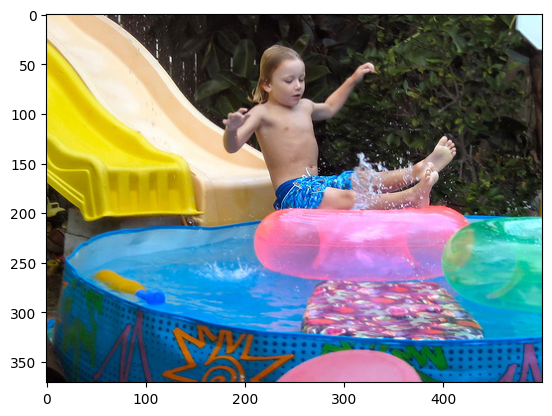

In [16]:
image_name = "1077546505_a4f6c4daa9.jpg"
image_id = image_name.split('.')[0]
img_path = os.path.join(Base_dir, "Images", image_name)
image = Image.open(img_path)
plt.imshow(image)

In [17]:
data = pd.read_csv("captionsreal.txt")
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


# 2- Image Feature Extraction 🖼️🔍

### Transfer Learning (VGG16)

![fjefj](https://storage.googleapis.com/lds-media/images/vgg16-architecture.width-1200.jpg)

In [18]:
model=VGG16()
model=Model(inputs=model.inputs, outputs=model.layers[-2].output)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
import tensorflow as tf
import keras
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

TensorFlow: 2.21.0
Keras: 3.12.1


### Storing the features

In [7]:
features={}
directory=os.path.join(Base_dir,'Images')
for img_name in tqdm(os.listdir(directory)):
    try:
        img_path=directory +'/'+ img_name
        image=load_img(img_path,target_size=(224,224))
        image=image.convert('RGB')
        image=img_to_array(image)
        image=image.reshape(1,image.shape[0],image.shape[1],image.shape[2])
        image=preprocess_input(image)
        feature=model.predict(image,verbose=0)
        image_id=img_name.split('.')[0]
        features[image_id]=feature
    except Exception as e:
        print(f"Skipping {img_name}: {e}")

print(f"✅ Done! Total features: {len(features)}")

  0%|          | 0/8091 [00:00<?, ?it/s]

Skipping .ipynb_checkpoints: [Errno 13] Permission denied: 'C:\\ImageCaptionProject\\Image-Caption-Generation-Project\\Images/.ipynb_checkpoints'
✅ Done! Total features: 8090


# 3-Text Preprocessing ✏️🧹

### Opening the captions text file

In [9]:
with open(os.path.join(Base_dir,'captionsreal.txt'),'r') as File:
    next(File)
    captions_file=File.read()

### Dictionary mapping image IDs to their captions

In [21]:
mapping = {}
for line in captions_file.split('\n'):
    tokens = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    image_id = image_id.split('.')[0]
    caption = " ".join(caption)
    if image_id not in mapping:
        mapping[image_id] = []
    mapping[image_id].append(caption)

In [22]:
def preprocessing(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i].lower()
            caption = caption.replace('[^A-Za-z]', '')
            caption = caption.replace('\s+', ' ')
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word) > 1]) + ' endseq'
            captions[i] = caption

preprocessing(mapping)

# 4-Tokenization and Splitting 📝🔡

In [23]:
#Used to extract all captions from the mapping dictionary into a single list
all_captions = [caption for key in mapping for caption in mapping[key]]


In [24]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in all_captions)

# 5- Splitting data into train and test ✂️📊

In [25]:
# Get the image IDs
image_ids = list(mapping.keys())

# Split into train and test sets (90% train, 10% test)
train, test = train_test_split(image_ids, test_size=0.1, random_state=42)

# 6. Data Generation (To Avoid Memory Issues) 🔄📦

In [26]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = [] , [] ,[] 
    n = 0
    while True:
        for key in data_keys:
            captions = mapping[key]
            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X1.append(features[key][0])
                    X2.append(in_seq)
                    y.append(out_seq)
            n += 1
            if n == batch_size:
                yield {"image": np.array(X1), "text": np.array(X2)}, np.array(y)
                X1.clear()  # Clears the content of X1
                X2.clear()  # Clears the content of X2
                y.clear()   # Clears the content of y
                n = 0

# 7. Model Architecture 🏗️🧠

In [27]:
# image feature layers
#4096 is the output of second last layer of the vgg16
inputs1=Input(shape=(4096,),name="image")
a=Dropout(0.3)(inputs1)
X=Dense(256,activation='relu')(a)

# sequence feature layers
inputs2=Input(shape=(max_length,),name="text")
c=Embedding(vocab_size,256)(inputs2)
d=Dropout(0.3)(c)
Y=LSTM(256)(d)



decoder1=add([X , Y])
decoder2=Dense(256,activation='relu')(decoder1)
outputs=Dense(vocab_size,activation='softmax')(decoder2)

model=Model(inputs=[inputs1,inputs2],outputs=outputs)
model.compile(loss='categorical_crossentropy',optimizer='adam')

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 35)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 4096)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 256)   │  2,172,160 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 35, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8485)      │  2,180,645 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,992,741 (22.86 MB)

 Trainable params: 5,992,741 (22.86 MB)

 Non-trainable params: 0 (0.00 B)

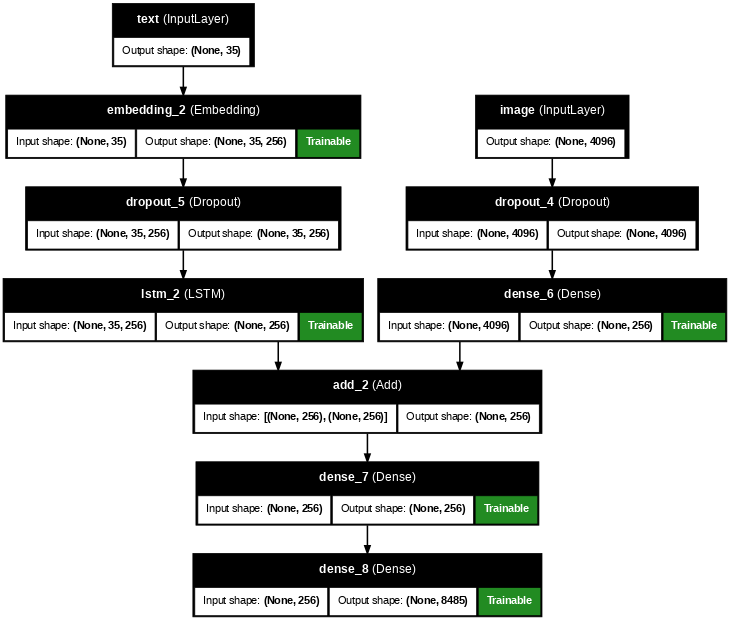

In [22]:
tf.keras.utils.plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    dpi=55,
    show_layer_activations=False,
    show_trainable=True
)

In [16]:
# Remove image IDs from train/test that don't have features extracted
train = [img_id for img_id in train if img_id in features]
test  = [img_id for img_id in test  if img_id in features]

print(f"Training images after cleanup: {len(train)}")
print(f"Testing images after cleanup:  {len(test)}")

Training images after cleanup: 7280
Testing images after cleanup:  810


In [21]:
import pickle

# Save features to disk so RAM is freed
pickle.dump(features, open('features_30k.pkl', 'wb'))
print(f"Features saved! Total: {len(features)}")

Features saved! Total: 8090


In [20]:
import pickle

# Load back from disk
features = pickle.load(open('features_30k.pkl', 'rb'))
print(f"Features loaded: {len(features)}")

Features loaded: 8090


In [22]:
from sklearn.model_selection import train_test_split

image_ids = list(mapping.keys())
train, test = train_test_split(image_ids, test_size=0.1, random_state=42)

# Clean up missing features
train = [img_id for img_id in train if img_id in features]
test  = [img_id for img_id in test  if img_id in features]

print(f"Train size: {len(train)}")
print(f"Test size:  {len(test)}")

Train size: 7280
Test size:  810


In [ ]:
# Verify save
import os
size = os.path.getsize(r'C:\ImageCaptionProject\Image-Caption-Generation-Project\features_30k.pkl') / (1024*1024)
print(f"✅ features_30k.pkl size: {size:.2f} MB")

In [63]:
import pickle
features = pickle.load(open('features_30k.pkl', 'rb'))
print(f"✅ Features loaded: {len(features)}")

✅ Features loaded: 0


In [64]:
import os
path = r'C:\ImageCaptionProject\Image-Caption-Generation-Project\features_30k.pkl'
size = os.path.getsize(path) / (1024*1024)
print(f"File size: {size:.2f} MB")

File size: 0.00 MB


In [65]:
import os
path = r'C:\ImageCaptionProject\Image-Caption-Generation-Project\features_30k.pkl'
os.remove(path)
print("✅ Deleted empty file")

✅ Deleted empty file


# 8- Training the model 🏋️‍♂️📈

In [23]:
epochs=12
batch_size=32
steps=len(train)//batch_size

for i in range(epochs):
    generator=data_generator(train,mapping,features,tokenizer,max_length,vocab_size,batch_size)
    model.fit(generator, epochs=1,steps_per_epoch=steps,verbose=1)

227/227 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - loss: 5.0614
227/227 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - loss: 3.8765
227/227 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step - loss: 3.4580
227/227 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - loss: 3.1869
227/227 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - loss: 2.9951
227/227 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - loss: 2.8555
227/227 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - loss: 2.7502
227/227 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - loss: 2.6620
227/227 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - loss: 2.5840
227/227 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - loss: 2.5141
227/227 ━━━━━━━━━━━━━━━━━━━━ 656s 3s/step - loss: 2.4472
227/227 ━━━━━━━━━━━━━━━━━━━━ 1316s 6s/step - loss: 2.3955


# 9- Generate Captions for the Image 🖼️📝

In [24]:
def convert_to_word(number, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == number:
            return word
    return None


def predict_caption(model, image, tokenizer, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], max_length)
        y_pred = model.predict([image, sequence], verbose=0)
        y_pred = np.argmax(y_pred)
        word = convert_to_word(y_pred, tokenizer)
        if word is None:
            break
        in_text += " " + word
        if word == 'endseq':
            break
      
    return in_text


In [25]:
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    image_id = image_name.split('.')[0]
    img_path = os.path.join(Base_dir, "Images", image_name)
    image = Image.open(img_path)
    # predict the caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print(y_pred)
    plt.imshow(image)

startseq brown dog is playing in the grass endseq


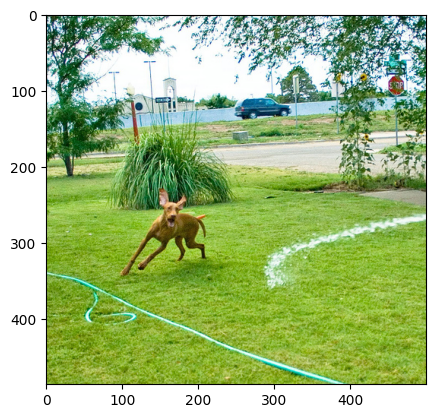

In [26]:
generate_caption("1019077836_6fc9b15408.jpg")


In [27]:
import sys
print(sys.executable)

c:\Users\Palak\caption_env\Scripts\python.exe


In [28]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Palak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# 10- BLEU Score 📊💙

In [29]:
from nltk.translate.bleu_score import corpus_bleu
# validate with test data
actual, predicted = [] , []

for key in tqdm(test):

    captions = mapping[key] 
    # predict the caption for image
    y_pred = predict_caption(model, features[key], tokenizer, max_length)
    # split into words
    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()
    # append to the list
    actual.append(actual_captions)
    predicted.append(y_pred)

    # calcuate BLEU score
#Unigram
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
#Bigram
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.553798
BLEU-2: 0.333083


# 11- Saving The model 💾📥

In [ ]:
model.save('model.h5')


In [31]:
pickle.dump(tokenizer , open('tokenizer.pkl','wb'))

In [32]:
import os
print(os.getcwd())  # This shows where model.h5 will be saved

c:\ImageCaptionProject\Image-Caption-Generation-Project


In [33]:
import os
path = r'C:\ImageCaptionProject\Image-Caption-Generation-Project\model.h5'
size = os.path.getsize(path)
print(f"model.h5 size: {size / (1024*1024):.2f} MB")

model.h5 size: 68.63 MB


# 12- Text-To-Speech 🗣️🔊

In [34]:
!pip install gtts

In [35]:
# listen to predicted text
from gtts import gTTS
from IPython.display import Audio, display

In [36]:
caption_text = ' '.join(y_pred)

# Now, replace 'startseq' and 'endseq' and strip the caption
caption_text = caption_text.replace('startseq', '').replace('endseq', '').strip()
# Display the predicted caption
print("Predicted Caption:", caption_text)

# Step 1: Generate the audio for the caption using gTTS
tts = gTTS(caption_text, lang='en')
audio_path = "predicted_caption.mp3"
tts.save(audio_path)

# Step 2: Display the audio player before the image
print("Playing the predicted caption audio:")
display(Audio(audio_path, autoplay=True))

Predicted Caption: two dogs are in water in water
Playing the predicted caption audio:


In [37]:
# Save the model
model.save("vgg16_model.keras")
print("Model saved!")

Model saved!


In [28]:
from tensorflow.keras.models import load_model

model = load_model("vgg16_model.keras")
print("Model loaded!")

Model loaded!


c:\ImageCaptionProject\caption_env\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
